# International Debt Analysis — Steps 1 & 2 (Complete)

## Sections Covered
- **Step 1** : Data Collection — Load all 5 CSV files
- **Step 2a**: Preprocessing df1 — Drop duplicates, future cols, melt to long format, ffill/bfill
- **Step 2b**: Preprocessing df2, df3, df4, df5 — Drop duplicates, check nulls
- **Step 2c**: Critical Fix — Strip trailing spaces in Country Code
- **Step 2d**: Merge — df_long + df2 (Country Metadata) + df4 (Series Metadata) → df_final

> **Output:** `df_final` — fully merged, clean dataset ready for Step 3 EDA

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 — Data Collection

In [2]:
# Load all 5 datasets

df1 = pd.read_csv(r"C:\Users\USER\Desktop\Project_02_International_Debt\IDS_ALLCountries_Data.csv",    encoding='latin1')
df2 = pd.read_csv(r"C:\Users\USER\Desktop\Project_02_International_Debt\IDS_CountryMetaData.csv",       encoding='latin1')
df3 = pd.read_csv(r"C:\Users\USER\Desktop\Project_02_International_Debt\Country-Series_Metadata.csv",   encoding='latin1')
df4 = pd.read_csv(r"C:\Users\USER\Desktop\Project_02_International_Debt\IDS_SeriesMetaData.csv",        encoding='latin1')
df5 = pd.read_csv(r"C:\Users\USER\Desktop\Project_02_International_Debt\IDS_FootnoteMetaData.csv",      encoding='latin1')

print('Datasets loaded successfully')

Datasets loaded successfully


In [3]:
# Check shapes of all datasets

print('df1 (Main Data)         :', df1.shape)
print('df2 (Country Metadata)  :', df2.shape)
print('df3 (Country-Series)    :', df3.shape)
print('df4 (Series Metadata)   :', df4.shape)
print('df5 (Footnote Metadata) :', df5.shape)

df1 (Main Data)         : (62983, 39)
df2 (Country Metadata)  : (134, 30)
df3 (Country-Series)    : (375, 4)
df4 (Series Metadata)   : (574, 12)
df5 (Footnote Metadata) : (2673, 5)


### View Main Dataset — df1

In [4]:
df1.head()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,...,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
0,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.DPPG,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.OFFT,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,World,WLD,Average grace period on new external debt comm...,DT.GPA.PRVT,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.DPPG,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,World,WLD,Average grant element on new external debt com...,DT.GRE.OFFT,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2a — Preprocessing : df1 (IDS_ALLCountries_Data.csv)

Tasks:
- Remove duplicates
- Drop future year columns (2025–2032)
- Convert year columns to numeric
- Melt wide format → long format
- Rename columns
- Handle missing values with ffill/bfill

In [5]:
# Remove duplicates from df1

df1 = df1.drop_duplicates()
print('Duplicates removed')
print('Shape after removing duplicates :', df1.shape)

Duplicates removed
Shape after removing duplicates : (62981, 39)


In [6]:
# Drop future year columns — mostly NaN forecast data, not needed

future_cols = ['2025','2026','2027','2028','2029','2030','2031','2032']
df1.drop(columns=future_cols, inplace=True, errors='ignore')
print('Future year columns dropped')
print('Shape after dropping future cols :', df1.shape)

Future year columns dropped
Shape after dropping future cols : (62981, 31)


In [7]:
# Identify year columns dynamically

year_cols = [col for col in df1.columns if str(col).isdigit()]
print('Year columns found :', len(year_cols))
print('Range :', year_cols[0], '-', year_cols[-1])

Year columns found : 25
Range : 2000 - 2024


In [8]:
# Convert year columns to numeric — invalid values become NaN

df1[year_cols] = df1[year_cols].apply(pd.to_numeric, errors='coerce')
print('Year columns converted to numeric')

Year columns converted to numeric


In [9]:
# Melt wide format to long format
# Before : 1 row = 1 country + 1 indicator, year values spread across 25 columns
# After  : 1 row = 1 country + 1 indicator + 1 year + 1 debt value

id_columns = ['Country Name', 'Country Code', 'Series Name', 'Series Code']

df_long = pd.melt(
    df1,
    id_vars    = id_columns,
    value_vars = year_cols,
    var_name   = 'year',
    value_name = 'debt_value'
)

print('Shape after melt :', df_long.shape)
df_long.head()

Shape after melt : (1574525, 6)


,Country Name,Country Code,Series Name,Series Code,year,debt_value
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,NaN
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,NaN
2,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,NaN
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,2000,NaN
4,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,2000,NaN


In [10]:
# Rename columns for clarity and SQL compatibility

df_long.rename(columns={
    'Series Name' : 'indicator',
    'Series Code' : 'indicator_code'
}, inplace=True)

print('Columns renamed')
print('Columns :', df_long.columns.tolist())

Columns renamed
Columns : ['Country Name', 'Country Code', 'indicator', 'indicator_code', 'year', 'debt_value']


In [11]:
# Ensure year and debt_value are numeric

df_long['year']       = pd.to_numeric(df_long['year'],       errors='coerce')
df_long['debt_value'] = pd.to_numeric(df_long['debt_value'], errors='coerce')
print('year and debt_value confirmed as numeric')

year and debt_value confirmed as numeric


In [12]:
# Handle missing debt values using forward-fill then back-fill
# Grouped by Country + Indicator to avoid mixing unrelated data

df_long['debt_value'] = (
    df_long
    .groupby(['Country Code', 'indicator_code'])['debt_value']
    .transform(lambda x: x.ffill().bfill())
)
print('Missing values handled with ffill / bfill')
print('Remaining NaN in debt_value :', df_long['debt_value'].isnull().sum())

Missing values handled with ffill / bfill
Remaining NaN in debt_value : 87075


In [13]:
# Just a quick check to see if the data looks correct after all transformations
# We will filter for Afghanistan and the indicator code 'DT.GPA.DPPG' (Gross Public Debt as % of GDP)
# This will allow us to verify that the year and debt_value columns are correct and that the data is in the expected long format.

filtered_df_sample = df_long[
    (df_long['Country Name'] == 'Afghanistan') &
    (df_long['indicator_code'] == 'DT.GPA.DPPG')
]

print(filtered_df_sample[['year', 'debt_value']])

         year  debt_value
0        2000     10.2500
62981    2001     10.2500
125962   2002     10.2500
188943   2003     10.2500
251924   2004     10.2500
314905   2005     10.2500
377886   2006     10.2500
440867   2007      8.0833
503848   2008      9.9575
566829   2009      0.0000
629810   2010      7.8333
692791   2011      0.0000
755772   2012      0.0000
818753   2013      0.0000
881734   2014     29.8333
944715   2015      0.0000
1007696  2016      0.0000
1070677  2017     19.8356
1133658  2018      0.0000
1196639  2019     17.9041
1259620  2020      0.0000
1322601  2021      0.0000
1385582  2022      0.0000
1448563  2023      0.0000
1511544  2024      0.0000


In [14]:
# Save intermediate cleaned file

df_long.to_csv('cleaned_debt_data.csv', index=False)
print('cleaned_debt_data.csv saved successfully')
print('Shape :', df_long.shape)

cleaned_debt_data.csv saved successfully
Shape : (1574525, 6)


## Step 2b — Preprocessing : df2, df3, df4, df5

Tasks for each file:
- Remove duplicates
- Check and understand null values

In [15]:
# ── df2 : IDS_CountryMetaData.csv ──────────────────────────────────────────

print('=== df2 : IDS_CountryMetaData.csv ===')
print('Shape before :', df2.shape)

df2 = df2.drop_duplicates()
print('Duplicates   :', df2.duplicated().sum())
print('Shape after  :', df2.shape)

print('\nNull value counts :')
print(df2.isnull().sum())

# Note: Nulls in Income Group, Region, Lending category are REGIONAL AGGREGATE rows
# e.g. EAP (East Asia & Pacific), IDA total, LIC (Low income) — not missing data
print('\nSample null Income Group rows (regional aggregates) :')
print(df2[df2['Income Group'].isnull()][['Code', 'Short Name']].to_string())

=== df2 : IDS_CountryMetaData.csv ===
Shape before : (134, 30)
Duplicates   : 0
Shape after  : (134, 30)

Null value counts :
Code                                                  0
Long Name                                             0
Income Group                                         15
Region                                               14
Lending category                                     14
Other groups                                         94
Currency Unit                                        14
Latest population census                             16
Latest household survey                              14
Special Notes                                        74
National accounts base year                          14
National accounts reference year                     95
System of National Accounts                          14
SNA price valuation                                  14
PPP survey years                                     18
Balance of Payments Manual in use 

In [16]:
# ── df3 : Country-Series_Metadata.csv ──────────────────────────────────────

print('=== df3 : Country-Series_Metadata.csv ===')
print('Shape before :', df3.shape)

df3 = df3.drop_duplicates()
print('Duplicates   :', df3.duplicated().sum())
print('Shape after  :', df3.shape)

print('\nNull value counts :')
print(df3.isnull().sum())

# Note: df3 is a REFERENCE file — explains special methodology notes
# for specific Country + Indicator combinations. Not merged into main data.
print('\nSample rows :')
print(df3.head(5).to_string())

=== df3 : Country-Series_Metadata.csv ===
Shape before : (375, 4)
Duplicates   : 0
Shape after  : (375, 4)

Null value counts :
Type            0
Country Code    0
Series Code     0
Description     0
dtype: int64

Sample rows :
             Type       Country Code                                                                                         Series Code                                                                                                                                                                                                                                                                                                                                                                  Description
0  Country-Series  Afghanistan (AFG)  Foreign direct investment, net inflows in reporting economy (DRS, current US$) (BX.KLT.DINV.CD.DT)                                                                                                                                      

In [17]:
# ── df4 : IDS_SeriesMetaData.csv ────────────────────────────────────────────

print('=== df4 : IDS_SeriesMetaData.csv ===')
print('Shape before :', df4.shape)

df4 = df4.drop_duplicates()
print('Duplicates   :', df4.duplicated().sum())
print('Shape after  :', df4.shape)

print('\nNull value counts :')
print(df4.isnull().sum())

# Note: License Type, Limitations, General comments have high nulls
# These are optional descriptive fields — not needed for analysis
# We will select only: Code, Indicator Name, Short definition, Topic
print('\nUseful columns preview :')
print(df4[['Code', 'Indicator Name', 'Short definition', 'Topic']].head(5).to_string())

=== df4 : IDS_SeriesMetaData.csv ===
Shape before : (574, 12)
Duplicates   : 0
Shape after  : (574, 12)

Null value counts :
Code                            0
License Type                  572
Indicator Name                  0
Short definition                2
Long definition                 0
Source                          0
Topic                           0
Dataset                         1
Periodicity                     0
Aggregation method              0
Limitations and exceptions    573
General comments              566
dtype: int64

Useful columns preview :
          Code                                                           Indicator Name                                                                                                                                                                                                                                                                                                                                                     

In [18]:
# ── df5 : IDS_FootNoteMetaData.csv ──────────────────────────────────────────

print('=== df5 : IDS_FootNoteMetaData.csv ===')
print('Shape before :', df5.shape)

df5 = df5.drop_duplicates()
print('Duplicates   :', df5.duplicated().sum())
print('Shape after  :', df5.shape)

print('\nNull value counts :')
print(df5.isnull().sum())

# Note: df5 is a REFERENCE file — year-level footnotes for Country + Indicator + Year
# Used as a lookup to explain unusual values during EDA. Not merged into main data.
print('\nSample rows :')
print(df5.head(5).to_string())

=== df5 : IDS_FootNoteMetaData.csv ===
Shape before : (2673, 5)
Duplicates   : 0
Shape after  : (2673, 5)

Null value counts :
Type            0
Country Code    0
Series Code     0
Time Code       0
Description     0
dtype: int64

Sample rows :
       Type       Country Code                                                                                         Series Code      Time Code                                                                                                                                                                                                                                 Description
0  FootNote  Afghanistan (AFG)        Personal transfers and compensation of employees, received (current US$) (BX.TRF.PWKR.CD.DT)  2024 (YR2024)  Data on Personal Transfers and Compensation of Employees are prepared by World Bank staff based on IMF's Balance of Payments statistics and data releases from central banks, national statistical agencies, and World Bank countr

In [19]:
# ── Summary of all 5 datasets after cleaning ────────────────────────────────

summary = pd.DataFrame({
    'DataFrame'  : ['df_long', 'df2', 'df3', 'df4', 'df5'],
    'Source File': [
        'IDS_ALLCountries_Data.csv',
        'IDS_CountryMetaData.csv',
        'Country-Series_Metadata.csv',
        'IDS_SeriesMetaData.csv',
        'IDS_FootNoteMetaData.csv'
    ],
    'Role'       : ['Main data', 'Country info', 'Country-indicator notes', 'Indicator definitions', 'Year footnotes'],
    'Will Merge' : ['Base', 'YES — Merge 1', 'No — reference only', 'YES — Merge 2', 'No — reference only']
})

print(summary.to_string(index=False))

DataFrame                 Source File                    Role          Will Merge
  df_long   IDS_ALLCountries_Data.csv               Main data                Base
      df2     IDS_CountryMetaData.csv            Country info       YES — Merge 1
      df3 Country-Series_Metadata.csv Country-indicator notes No — reference only
      df4      IDS_SeriesMetaData.csv   Indicator definitions       YES — Merge 2
      df5    IDS_FootNoteMetaData.csv          Year footnotes No — reference only


## Step 2c — Critical Fix : Strip Trailing Spaces in Country Code

> The `Country Code` column in `df_long` has **trailing spaces**  
> e.g. `'AFG       '` instead of `'AFG'`  
> Without this fix the merge with df2 returns **0 matching rows**

In [20]:
# Strip trailing spaces from Country Code

print('Before strip:', repr(df_long['Country Code'].iloc[0]))

df_long['Country Code'] = df_long['Country Code'].str.strip()

print('After strip :', repr(df_long['Country Code'].iloc[0]))
print('Fix applied successfully')

Before strip: 'AFG       '
After strip : 'AFG'
Fix applied successfully


## Step 2d — Merge : Build df_final

- **Merge 1** : df_long + df2 → join on `Country Code` → adds Region, Income Group, Lending category
- **Merge 2** : result + df4 → join on `indicator_code` → adds Indicator Name, Short definition, Topic
- df3, df5 kept as reference lookup files only

In [21]:
# Select only useful columns from df2 (6 out of 30 columns)

df2_selected = df2[[
    'Code',             # join key = Country Code
    'Short Name',       # country short name
    'Income Group',     # Low / Lower middle / Upper middle / High income
    'Region',           # East Asia, South Asia, Sub-Saharan Africa, etc.
    'Lending category', # IDA / IBRD / Blend
    'Currency Unit'     # country currency
]].copy()

# Select only useful columns from df4 (4 out of 12 columns)

df4_selected = df4[[
    'Code',             # join key = indicator_code
    'Indicator Name',   # full indicator name
    'Short definition', # what the indicator measures
    'Topic'             # category e.g. External Debt, Financial Sector
]].copy()

print('df2_selected shape :', df2_selected.shape)
print('df4_selected shape :', df4_selected.shape)

df2_selected shape : (134, 6)
df4_selected shape : (574, 4)


In [22]:
# Merge 1 : df_long + df2_selected
# Join key  : df_long['Country Code'] == df2_selected['Code']
# Join type : left — keep all rows from df_long

df_merged = pd.merge(
    df_long,
    df2_selected,
    left_on  = 'Country Code',
    right_on = 'Code',
    how      = 'left'
)

# Drop duplicate 'Code' column (same as Country Code)
df_merged.drop(columns=['Code'], inplace=True)

print('df_long shape  :', df_long.shape)
print('df_merged shape:', df_merged.shape)
print('New columns added : Short Name, Income Group, Region, Lending category, Currency Unit')

df_long shape  : (1574525, 6)
df_merged shape: (1574525, 11)
New columns added : Short Name, Income Group, Region, Lending category, Currency Unit


In [23]:
# Merge 2 : df_merged + df4_selected
# Join key  : df_merged['indicator_code'] == df4_selected['Code']
# Join type : left — keep all rows from df_merged

df_final = pd.merge(
    df_merged,
    df4_selected,
    left_on  = 'indicator_code',
    right_on = 'Code',
    how      = 'left'
)

# Drop duplicate 'Code' column (same as indicator_code)
df_final.drop(columns=['Code'], inplace=True)

print('df_merged shape :', df_merged.shape)
print('df_final shape  :', df_final.shape)
print('New columns added : Indicator Name, Short definition, Topic')
print('\nAll columns in df_final :')
print(df_final.columns.tolist())

df_merged shape : (1574525, 11)
df_final shape  : (1574525, 14)
New columns added : Indicator Name, Short definition, Topic

All columns in df_final :
['Country Name', 'Country Code', 'indicator', 'indicator_code', 'year', 'debt_value', 'Short Name', 'Income Group', 'Region', 'Lending category', 'Currency Unit', 'Indicator Name', 'Short definition', 'Topic']


In [24]:
# Final inspection of df_final

print('=== df_final : Final Merged Dataset ===')
print('Shape :', df_final.shape)

print('\nNull values in key columns :')
key_cols = ['Country Code', 'indicator_code', 'year', 'debt_value', 'Income Group', 'Region', 'Topic']
print(df_final[key_cols].isnull().sum())

print('\nSample rows :')
df_final.head()

=== df_final : Final Merged Dataset ===
Shape : (1574525, 14)

Null values in key columns :
Country Code          75
indicator_code        75
year                   0
debt_value         87075
Income Group      209950
Region            198300
Topic             103825
dtype: int64

Sample rows :


,Country Name,Country Code,indicator,indicator_code,year,debt_value,Short Name,Income Group,Region,Lending category,Currency Unit,Indicator Name,Short definition,Topic
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,10.2500,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,10.2500,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
2,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,0.0000,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,2000,50.6176,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,Economic Policy & Debt: External debt: Terms
4,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,2000,50.6176,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,Economic Policy & Debt: External debt: Terms


## ⚙️ Optional — Remove Rows Where `debt_value = 0`

> **When to use this:**  
> A `debt_value` of `0` can mean the country truly had zero debt for that indicator in that year,  
> OR it can be a data entry placeholder for missing/unreported data.  
> Run this block **only if** you want to exclude zero-debt rows from your analysis.

> **Note:** This is an optional step — `df_final` remains unchanged unless you run this cell.

In [25]:
# ── OPTIONAL : Remove rows where debt_value = 0 ─────────────────────────────
# Run this block only if your analysis should exclude zero-debt rows

print('Shape before removing zero debt_value rows :', df_final.shape)

# Count how many rows have debt_value == 0
zero_count = (df_final['debt_value'] == 0).sum()
print('Rows with debt_value = 0                   :', zero_count)
print('Percentage of total rows                   :', round(zero_count / len(df_final) * 100, 2), '%')

# Preview sample zero rows before removing
print('\nSample rows where debt_value = 0 :')
print(df_final[df_final['debt_value'] == 0][['Country Name', 'indicator_code', 'year', 'debt_value']].head(10).to_string())

# Remove rows where debt_value == 0
df_final = df_final[df_final['debt_value'] != 0].reset_index(drop=True)

print('\nShape after removing zero debt_value rows  :', df_final.shape)
print('Rows removed                               :', zero_count)

Shape before removing zero debt_value rows : (1574525, 14)
Rows with debt_value = 0                   : 221549
Percentage of total rows                   : 14.07 %

Sample rows where debt_value = 0 :
   Country Name  indicator_code  year  debt_value
2   Afghanistan     DT.GPA.PRVT  2000         0.0
5   Afghanistan     DT.GRE.PRVT  2000         0.0
8   Afghanistan     DT.INR.PRVT  2000         0.0
11  Afghanistan     DT.MAT.PRVT  2000         0.0
13  Afghanistan  DT.COM.MIDA.CD  2000         0.0
19  Afghanistan  DT.CUR.EURO.ZS  2000         0.0
20  Afghanistan  DT.CUR.JYEN.ZS  2000         0.0
21  Afghanistan  DT.CUR.MULC.ZS  2000         0.0
24  Afghanistan  DT.CUR.SWFR.ZS  2000         0.0
27  Afghanistan  DT.DSB.DPPG.CD  2000         0.0

Shape after removing zero debt_value rows  : (1352976, 14)
Rows removed                               : 221549


In [26]:
# Save df_final — ready for Step 3 EDA

df_final.to_csv('final_merged_debt_data.csv', index=False)
print('final_merged_debt_data.csv saved successfully')
print('Shape :', df_final.shape)
print('\ndf_final is ready for Step 3 : Exploratory Data Analysis (EDA)')

final_merged_debt_data.csv saved successfully
Shape : (1352976, 14)

df_final is ready for Step 3 : Exploratory Data Analysis (EDA)


# Step 3 — Exploratory Data Analysis (EDA)

## 8 Key Analyses
| # | Analysis |
|---|----------|
| EDA 1 | Dataset Overview |
| EDA 2 | Filter Actual Countries (exclude regional aggregates) |
| EDA 3 | Descriptive Statistics |
| EDA 4 | Top 10 Countries — Highest Total Debt |
| EDA 5 | Year-wise Global Debt Trend (2000–2024) + Growth Rate |
| EDA 6 | Debt Distribution by Income Group |
| EDA 7 | Debt Distribution by Region |
| EDA 8 | Outlier Detection — IQR Method |

> **Input :** `df_final` already in memory from Step 2  
> **Output :** 6 chart PNG files + printed insight tables

## Import EDA Libraries

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11

print('EDA libraries imported successfully')
print('df_final is already in memory from Step 2 — no reload needed')
print('df_final shape :', df_final.shape)

EDA libraries imported successfully
df_final is already in memory from Step 2 — no reload needed
df_final shape : (1352976, 14)


## EDA 1 — Dataset Overview

In [28]:
print('=== EDA 1 : Dataset Overview ===')
print(f'Total Rows        : {df_final.shape[0]:,}')
print(f'Total Columns     : {df_final.shape[1]}')
print(f'Year Range        : {int(df_final["year"].min())} - {int(df_final["year"].max())}')
print(f'Unique Countries  : {df_final["Country Code"].nunique()}')
print(f'Unique Indicators : {df_final["indicator_code"].nunique()}')
print()
print('Column Data Types :')
print(df_final.dtypes)
print()
print('Null Value Counts :')
print(df_final.isnull().sum())
print()
print('Sample Rows :')
df_final.head()

=== EDA 1 : Dataset Overview ===
Total Rows        : 1,352,976
Total Columns     : 14
Year Range        : 2000 - 2024
Unique Countries  : 134
Unique Indicators : 576

Column Data Types :
Country Name         object
Country Code         object
indicator            object
indicator_code       object
year                  int64
debt_value          float64
Short Name           object
Income Group         object
Region               object
Lending category     object
Currency Unit        object
Indicator Name       object
Short definition     object
Topic                object
dtype: object

Null Value Counts :
Country Name            25
Country Code            75
indicator               75
indicator_code          75
year                     0
debt_value           87075
Short Name              75
Income Group        200808
Region              190657
Lending category    190657
Currency Unit       190657
Indicator Name       88885
Short definition     95585
Topic                88885
dtype: i

,Country Name,Country Code,indicator,indicator_code,year,debt_value,Short Name,Income Group,Region,Lending category,Currency Unit,Indicator Name,Short definition,Topic
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,10.2500,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,10.2500,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
2,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,2000,50.6176,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,Economic Policy & Debt: External debt: Terms
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,2000,50.6176,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,Economic Policy & Debt: External debt: Terms
4,Afghanistan,AFG,Average interest on new external debt commitme...,DT.INR.DPPG,2000,1.2496,Afghanistan,Low income,Middle East & North Africa,IDA,Afghan afghani,Average interest on new external debt commitme...,Interest represents the average interest rate ...,Economic Policy & Debt: External debt: Terms


## EDA 2 — Filter Actual Countries

> `df_final` includes **regional aggregate rows** e.g. 'Low & middle income', 'IDA total'.  
> These rows have `Region = NaN` because they are not individual countries.  
> We create `df_countries` containing only individual country rows for all EDA charts.

In [29]:
df_countries = df_final[df_final['Region'].notna()].copy()
df_countries.reset_index(drop=True, inplace=True)

print('df_final rows              :', len(df_final))
print('df_countries rows          :', len(df_countries))
print('Regional aggregate rows    :', len(df_final) - len(df_countries))
print()
print('Unique individual countries:', df_countries['Country Code'].nunique())
print('Unique indicators          :', df_countries['indicator_code'].nunique())
print()
print('All EDA charts below use df_countries (individual countries only)')

df_final rows              : 1352976
df_countries rows          : 1162319
Regional aggregate rows    : 190657

Unique individual countries: 120
Unique indicators          : 576

All EDA charts below use df_countries (individual countries only)


## EDA 3 — Descriptive Statistics

In [30]:
stats = df_countries['debt_value'].describe()

print('=== Descriptive Statistics : debt_value ===')
print(f"  Count      : {stats['count']:>20,.0f}")
print(f"  Mean       : {stats['mean']:>20,.2f}")
print(f"  Median     : {df_countries['debt_value'].median():>20,.2f}")
print(f"  Std Dev    : {stats['std']:>20,.2f}")
print(f"  Min        : {stats['min']:>20,.2f}")
print(f"  25%        : {stats['25%']:>20,.2f}")
print(f"  75%        : {stats['75%']:>20,.2f}")
print(f"  Max        : {stats['max']:>20,.2f}")
print()
neg = (df_countries['debt_value'] < 0).sum()
zero = (df_countries['debt_value'] == 0).sum()
print(f'Negative debt_value rows : {neg:,}  (net flow / outflow indicators — valid values)')
print(f'Zero debt_value rows     : {zero:,}  (no debt reported for that year)')

=== Descriptive Statistics : debt_value ===
  Count      :            1,076,594
  Mean       :     2,278,943,142.15
  Median     :        16,738,258.75
  Std Dev    :    59,847,717,598.44
  Min        :  -445,000,000,000.00
  25%        :           102,080.25
  75%        :       251,358,501.50
  Max        : 18,600,000,000,000.00

Negative debt_value rows : 143,480  (net flow / outflow indicators — valid values)
Zero debt_value rows     : 0  (no debt reported for that year)


## EDA 5 — Top 10 Countries with Highest Total Debt

Top 10 Countries by Total Debt (2000-2024):
  China                                 620.22 Trillion USD
  India                                 190.94 Trillion USD
  Mexico                                188.89 Trillion USD
  Brazil                                187.51 Trillion USD
  Indonesia                             122.00 Trillion USD
  Turkiye                               119.18 Trillion USD
  Argentina                              71.45 Trillion USD
  Thailand                               52.28 Trillion USD
  South Africa                           48.44 Trillion USD
  Colombia                               46.32 Trillion USD


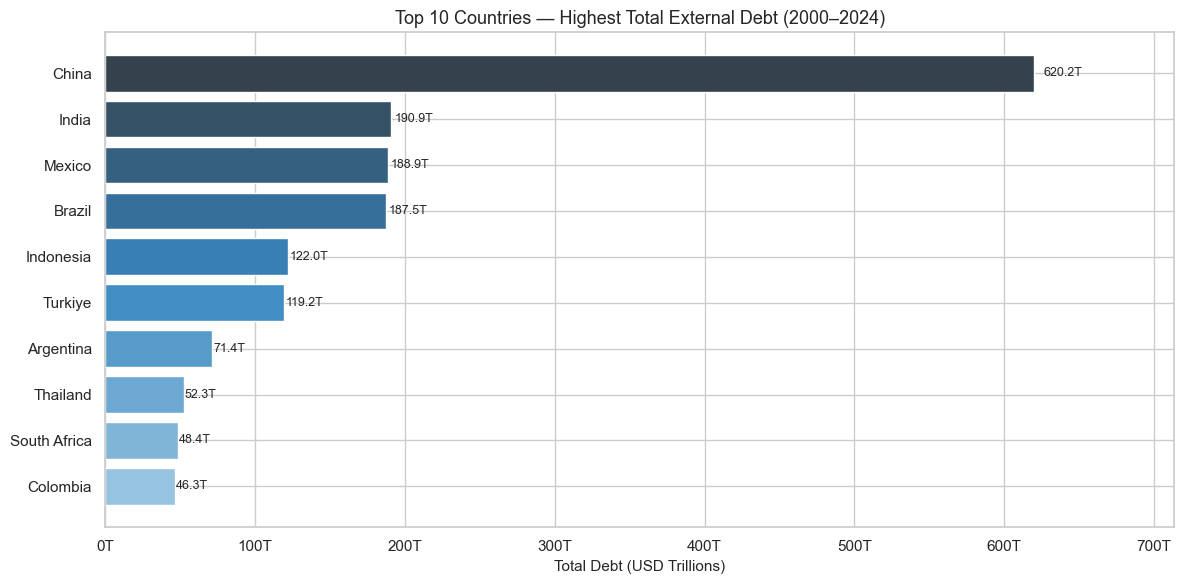

Saved: eda_05_top10_countries.png


In [31]:
top10 = (df_countries.groupby('Country Name')['debt_value']
         .sum().nlargest(10).reset_index())
top10.columns = ['Country', 'Total Debt']

print('Top 10 Countries by Total Debt (2000-2024):')
for _, r in top10.iterrows():
    print(f"  {r['Country']:<35} {r['Total Debt']/1e12:>8.2f} Trillion USD")

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Blues_d', 10)
bars = ax.barh(top10['Country'][::-1], top10['Total Debt'][::-1], color=colors)
for bar, val in zip(bars, top10['Total Debt'][::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val/1e12:.1f}T', va='center', fontsize=9)
ax.set_title('Top 10 Countries — Highest Total External Debt (2000–2024)')
ax.set_xlabel('Total Debt (USD Trillions)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e12:.0f}T'))
ax.set_xlim(0, top10['Total Debt'].max()*1.15)
plt.tight_layout()
plt.savefig('eda_05_top10_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_05_top10_countries.png')

## EDA 7 — Year-wise Global Debt Trend (2000–2024)

Year-wise Global Debt Summary:
 Year   Total Debt  YoY Growth (%)
 2000 3.904662e+13             NaN
 2001 3.861530e+13       -1.104621
 2002 3.893788e+13        0.835360
 2003 4.294414e+13       10.288839
 2004 4.651924e+13        8.325006
 2005 4.869407e+13        4.675111
 2006 5.353842e+13        9.948562
 2007 6.316310e+13       17.977128
 2008 6.822922e+13        8.020705
 2009 6.949096e+13        1.849268
 2010 8.381723e+13       20.616020
 2011 9.393750e+13       12.074208
 2012 1.018774e+14        8.452314
 2013 1.099637e+14        7.937260
 2014 1.182180e+14        7.506411
 2015 1.089838e+14       -7.811142
 2016 1.159558e+14        6.397250
 2017 1.321350e+14       13.952928
 2018 1.384636e+14        4.789484
 2019 1.426884e+14        3.051213
 2020 1.463076e+14        2.536397
 2021 1.631664e+14       11.522845
 2022 1.573153e+14       -3.585932
 2023 1.631171e+14        3.687984
 2024 1.683708e+14        3.220831


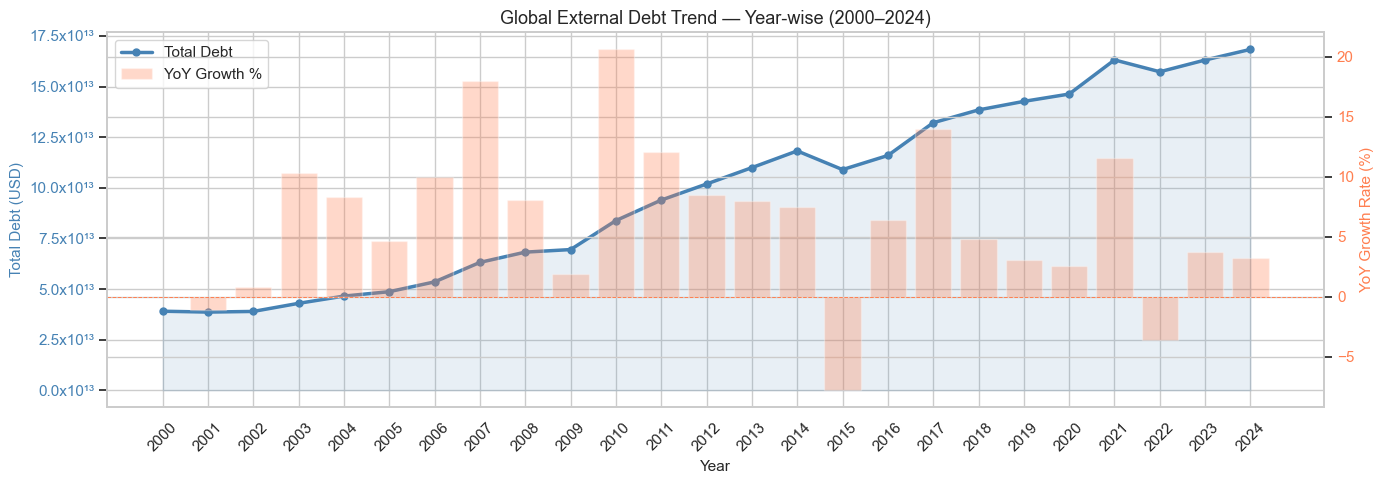

Saved: eda_07_yearly_trend.png


In [32]:
yearly = (df_countries.groupby('year')['debt_value']
          .sum().reset_index())
yearly.columns = ['Year','Total Debt']
yearly['YoY Growth (%)'] = yearly['Total Debt'].pct_change() * 100

print('Year-wise Global Debt Summary:')
print(yearly.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(yearly['Year'], yearly['Total Debt'],
         color='steelblue', linewidth=2.5, marker='o', markersize=5, label='Total Debt')
ax1.fill_between(yearly['Year'], yearly['Total Debt'], alpha=0.12, color='steelblue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Debt (USD)', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e13:.1f}x10¹³'))
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar(yearly['Year'], yearly['YoY Growth (%)'], alpha=0.3, color='coral', label='YoY Growth %')
ax2.axhline(0, color='coral', linewidth=0.7, linestyle='--')
ax2.set_ylabel('YoY Growth Rate (%)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_title('Global External Debt Trend — Year-wise (2000–2024)')
ax1.set_xticks(yearly['Year'])
ax1.tick_params(axis='x', rotation=45)
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, loc='upper left')

plt.tight_layout()
plt.savefig('eda_07_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_07_yearly_trend.png')

## EDA 8 — Debt Distribution by Income Group

Debt by Income Group:
  Upper middle income            1.7380 Quadrillion USD
  Lower middle income            0.6375 Quadrillion USD
  Low income                     0.0654 Quadrillion USD
  High income                    0.0010 Quadrillion USD


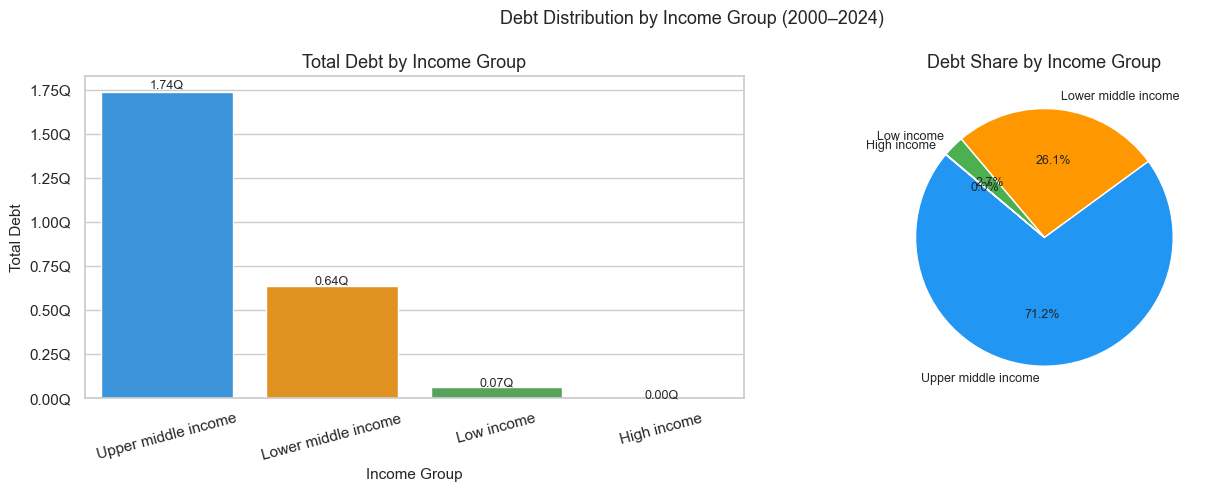

Saved: eda_08_income_group.png


In [33]:
inc = (df_countries.dropna(subset=['Income Group'])
       .groupby('Income Group')['debt_value']
       .sum().sort_values(ascending=False).reset_index())
inc.columns = ['Income Group','Total Debt']

print('Debt by Income Group:')
for _, r in inc.iterrows():
    print(f"  {r['Income Group']:<30} {r['Total Debt']/1e15:.4f} Quadrillion USD")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = ['#2196F3','#FF9800','#4CAF50','#9C27B0']
sns.barplot(data=inc, x='Income Group', y='Total Debt', palette=pal, ax=axes[0])
axes[0].set_title('Total Debt by Income Group')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e15:.2f}Q'))
axes[0].tick_params(axis='x', rotation=15)
for i, r in inc.iterrows():
    axes[0].text(i, r['Total Debt']*1.01, f"{r['Total Debt']/1e15:.2f}Q", ha='center', fontsize=9)

axes[1].pie(inc['Total Debt'], labels=inc['Income Group'],
            autopct='%1.1f%%', startangle=140, colors=pal, textprops={'fontsize':9})
axes[1].set_title('Debt Share by Income Group')

plt.suptitle('Debt Distribution by Income Group (2000–2024)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_08_income_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_08_income_group.png')

## EDA 9 — Debt Distribution by Region

Debt by Region:
  East Asia & Pacific                      9.02 x10¹⁴ USD
  Latin America & Caribbean                5.92 x10¹⁴ USD
  Europe & Central Asia                    2.70 x10¹⁴ USD
  Sub-Saharan Africa                       2.52 x10¹⁴ USD
  South Asia                               2.40 x10¹⁴ USD
  Middle East & North Africa               1.97 x10¹⁴ USD


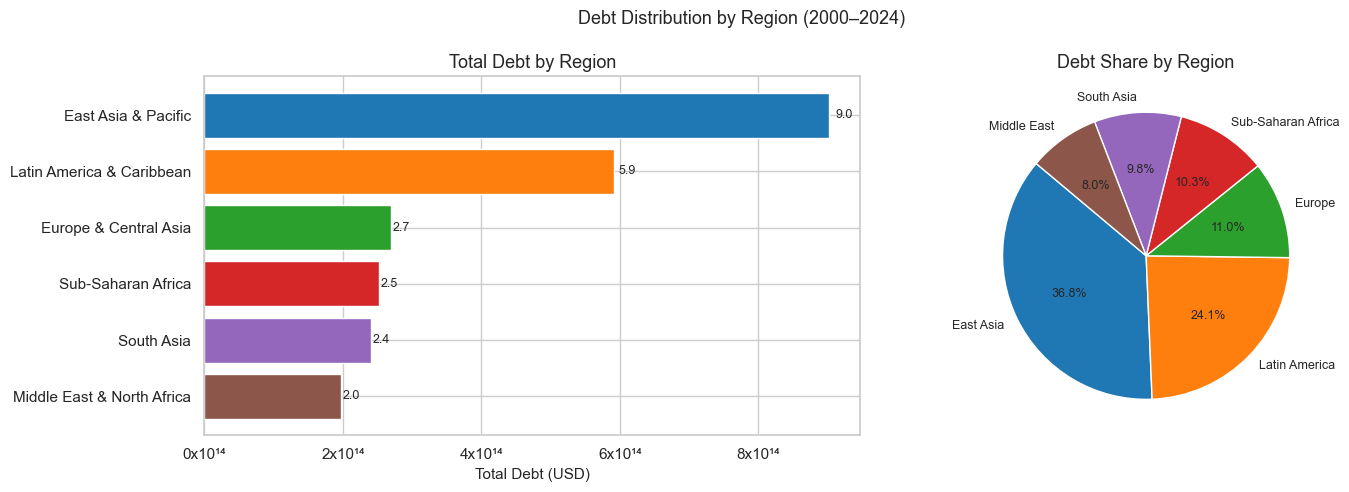

Saved: eda_09_region.png


In [34]:
reg = (df_countries.dropna(subset=['Region'])
       .groupby('Region')['debt_value']
       .sum().sort_values(ascending=False).reset_index())
reg.columns = ['Region','Total Debt']

print('Debt by Region:')
for _, r in reg.iterrows():
    print(f"  {r['Region']:<40} {r['Total Debt']/1e14:.2f} x10¹⁴ USD")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rcols = sns.color_palette('tab10', len(reg))
axes[0].barh(reg['Region'][::-1], reg['Total Debt'][::-1], color=rcols[::-1])
axes[0].set_title('Total Debt by Region')
axes[0].set_xlabel('Total Debt (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e14:.0f}x10¹⁴'))
for i,(v,_) in enumerate(zip(reg['Total Debt'][::-1], reg['Region'][::-1])):
    axes[0].text(v*1.01, i, f'{v/1e14:.1f}', va='center', fontsize=9)

short_lbl = [r.split('&')[0].strip() for r in reg['Region']]
axes[1].pie(reg['Total Debt'], labels=short_lbl, autopct='%1.1f%%',
            startangle=140, colors=rcols, textprops={'fontsize':9})
axes[1].set_title('Debt Share by Region')

plt.suptitle('Debt Distribution by Region (2000–2024)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_09_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_09_region.png')

## EDA 12 — Outlier Detection Using IQR Method

=== IQR Outlier Detection ===
Q1 (25th percentile)  :           102,080.25
Q3 (75th percentile)  :       251,358,501.50
IQR                   :       251,256,421.25
Lower Bound           :      -376,782,551.62
Upper Bound           :       628,243,133.38

Total rows            :  1,162,319
Outlier rows          :    199,784  (17.2%)
Non-outlier rows      :    876,810  (75.4%)

Top 10 Outlier Rows (highest debt_value):
Country Name         indicator  year   debt_value
       China GNI (current US$)  2024 1.860000e+13
       China GNI (current US$)  2022 1.820000e+13
       China GNI (current US$)  2021 1.810000e+13
       China GNI (current US$)  2023 1.810000e+13
       China GNI (current US$)  2020 1.490000e+13
       China GNI (current US$)  2019 1.450000e+13
       China GNI (current US$)  2018 1.410000e+13
       China GNI (current US$)  2017 1.250000e+13
       China GNI (current US$)  2016 1.140000e+13
       China GNI (current US$)  2015 1.120000e+13


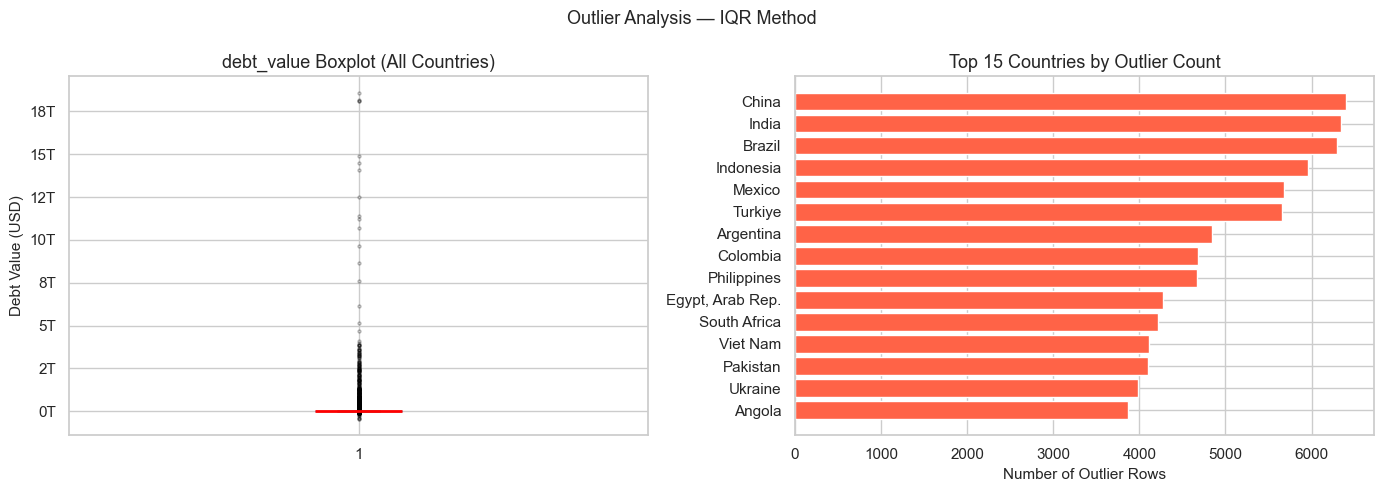

Saved: eda_12_outliers.png


In [35]:
Q1  = df_countries['debt_value'].quantile(0.25)
Q3  = df_countries['debt_value'].quantile(0.75)
IQR = Q3 - Q1
lower_b = Q1 - 1.5 * IQR
upper_b = Q3 + 1.5 * IQR

outliers = df_countries[(df_countries['debt_value'] < lower_b) |
                         (df_countries['debt_value'] > upper_b)]
non_out  = df_countries[(df_countries['debt_value'] >= lower_b) &
                         (df_countries['debt_value'] <= upper_b)]

print('=== IQR Outlier Detection ===')
print(f'Q1 (25th percentile)  : {Q1:>20,.2f}')
print(f'Q3 (75th percentile)  : {Q3:>20,.2f}')
print(f'IQR                   : {IQR:>20,.2f}')
print(f'Lower Bound           : {lower_b:>20,.2f}')
print(f'Upper Bound           : {upper_b:>20,.2f}')
print()
print(f'Total rows            : {len(df_countries):>10,}')
print(f'Outlier rows          : {len(outliers):>10,}  ({len(outliers)/len(df_countries)*100:.1f}%)')
print(f'Non-outlier rows      : {len(non_out):>10,}  ({len(non_out)/len(df_countries)*100:.1f}%)')
print()
print('Top 10 Outlier Rows (highest debt_value):')
print(outliers.nlargest(10,'debt_value')
      [['Country Name','indicator','year','debt_value']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df_countries['debt_value'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title('debt_value Boxplot (All Countries)')
axes[0].set_ylabel('Debt Value (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e12:.0f}T'))

out_by_c = outliers.groupby('Country Name').size().nlargest(15).reset_index()
out_by_c.columns = ['Country','Count']
axes[1].barh(out_by_c['Country'][::-1], out_by_c['Count'][::-1], color='tomato')
axes[1].set_title('Top 15 Countries by Outlier Count')
axes[1].set_xlabel('Number of Outlier Rows')

plt.suptitle('Outlier Analysis — IQR Method', fontsize=13)
plt.tight_layout()
plt.savefig('eda_12_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_12_outliers.png')

## EDA Summary — Key Insights

In [36]:
print('=' * 65)
print('STEP 3 EDA — KEY INSIGHTS')
print('=' * 65)

top1     = df_countries.groupby('Country Name')['debt_value'].sum().idxmax()
top1_val = df_countries.groupby('Country Name')['debt_value'].sum().max()
print(f'1. Highest debt country  : {top1} ({top1_val/1e12:.1f} Trillion USD)')

bot1     = df_countries[df_countries['debt_value']>0].groupby('Country Name')['debt_value'].sum().idxmin()
bot1_val = df_countries[df_countries['debt_value']>0].groupby('Country Name')['debt_value'].sum().min()
print(f'2. Lowest debt country   : {bot1} ({bot1_val/1e9:.1f} Billion USD)')

peak_yr  = df_countries.groupby('year')['debt_value'].sum().idxmax()
peak_val = df_countries.groupby('year')['debt_value'].sum().max()
print(f'3. Peak debt year        : {int(peak_yr)} ({peak_val/1e13:.2f} x10¹³ USD)')

top_inc  = df_countries.dropna(subset=['Income Group']).groupby('Income Group')['debt_value'].sum().idxmax()
print(f'4. Highest debt income   : {top_inc}')

top_reg  = df_countries.dropna(subset=['Region']).groupby('Region')['debt_value'].sum().idxmax()
print(f'5. Highest debt region   : {top_reg}')

top_ind_n = df_countries.groupby('indicator')['debt_value'].sum().idxmax()
print(f'6. Dominant indicator    : {top_ind_n[:65]}')

Q1 = df_countries['debt_value'].quantile(0.25)
Q3 = df_countries['debt_value'].quantile(0.75)
IQR = Q3 - Q1
out_pct = ((df_countries['debt_value']<Q1-1.5*IQR)|(df_countries['debt_value']>Q3+1.5*IQR)).mean()*100
print(f'7. Outlier percentage    : {out_pct:.1f}% of rows')

d2000 = df_countries[df_countries['year']==2000]['debt_value'].sum()
d2024 = df_countries[df_countries['year']==2024]['debt_value'].sum()
growth = (d2024 - d2000) / d2000 * 100
print(f'8. Debt growth 2000-2024 : +{growth:.1f}%')

print('=' * 65)
print('\nStep 3 EDA Complete — ready for Step 4 : SQL Integration')

STEP 3 EDA — KEY INSIGHTS
1. Highest debt country  : China (620.2 Trillion USD)
2. Lowest debt country   : Tonga (92.3 Billion USD)
3. Peak debt year        : 2024 (16.84 x10¹³ USD)
4. Highest debt income   : Upper middle income
5. Highest debt region   : East Asia & Pacific
6. Dominant indicator    : GNI (current US$)
7. Outlier percentage    : 17.2% of rows
8. Debt growth 2000-2024 : +331.2%

Step 3 EDA Complete — ready for Step 4 : SQL Integration


# Step 4 — Database Design & SQL Integration

## Overview
| Component | Detail |
|-----------|--------|
| Database  | MySQL — `international_debt_db` |
| Library   | `mysql-connector-python` |
| Tables    | `countries`, `indicators`, `debt_data` |
| SQL Queries | 30 total — 10 Basic + 10 Intermediate + 10 Advanced |

## Database Schema
```
countries          indicators         debt_data
─────────────      ──────────────     ──────────────────
country_code PK    indicator_code PK  id            PK
country_name       indicator_name     country_code
short_name         short_definition   indicator_code
income_group       topic              year
region                                debt_value
lending_category
currency_unit
```

## ⚠️ Drop & Recreate — Run Each Cell Below One by One

> Run **each cell in order** before every fresh re-run of Step 4.

| Cell | Step | Time |
|------|------|------|
| A | Connect to MySQL + set timeouts | instant |
| B | Check database exists + disable FK checks | instant |
| C | Batch-delete `debt_data` (100K rows/batch) | ~30–60 sec |
| D | Truncate `countries` + `indicators` + re-enable FK | instant |
| E | Drop the empty database | instant |
| F | Create fresh database + reassign `conn` / `cursor` | instant |

> **Skip all 6 cells** if running Step 4 for the very first time.

In [37]:
# ── Cell A : Connect to MySQL + Set Session Timeouts ────────────────────
import mysql.connector
import time

conn_admin = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = 'root'
)
cur = conn_admin.cursor()

cur.execute('SET SESSION wait_timeout        = 600')
cur.execute('SET SESSION interactive_timeout = 600')
cur.execute('SET SESSION net_read_timeout    = 600')

print('Cell A done — Connected to MySQL, timeouts set to 600 seconds')

Cell A done — Connected to MySQL, timeouts set to 600 seconds


In [38]:
# ── Cell B : Check Database Exists + Use It + Disable FK Checks ─────────
cur.execute("SHOW DATABASES LIKE 'international_debt_db_2'")
db_exists = cur.fetchone()

if db_exists:
    cur.execute('USE international_debt_db_2')
    cur.execute('SET FOREIGN_KEY_CHECKS = 0')
    print('Cell B done — Database found, FK checks disabled')
    print('Proceed to Cell C')
else:
    print('Cell B done — Database does NOT exist')
    print('Skip Cells C, D, E — go directly to Cell F')

Cell B done — Database does NOT exist
Skip Cells C, D, E — go directly to Cell F


In [39]:
# ── Cell C : Batch-Delete debt_data (100,000 rows per batch) ────────────
# WHY BATCH DELETE and not TRUNCATE:
#   TRUNCATE rebuilds the full ~300MB .ibd file in ONE transaction
#   → takes 2-5 mins → always hits Error 2013 connection timeout
#   Batch DELETE commits every 100K rows separately
#   → each batch ~2 sec → no timeout possible

'''cur.execute("SHOW TABLES LIKE 'debt_data'")
if cur.fetchone():
    cur.execute('SELECT COUNT(*) FROM debt_data')
    total_rows = cur.fetchone()[0]
    print(f'Rows to delete : {total_rows:,}')
    print('Deleting in batches of 100,000 rows...')

    start         = time.time()
    total_deleted = 0
    batch_num     = 0

    while True:
        cur.execute('DELETE FROM debt_data LIMIT 100000')
        conn_admin.commit()
        deleted = cur.rowcount
        if deleted == 0:
            break
        total_deleted += deleted
        batch_num     += 1
        pct            = total_deleted / total_rows * 100
        elapsed        = time.time() - start
        print(f'  Batch {batch_num:02d} : {deleted:>7,} rows deleted'
              f' | Total {total_deleted:>10,} ({pct:.0f}%)'
              f' | {elapsed:.1f}s')

    print(f'Cell C done — debt_data cleared : {total_deleted:,} rows'
          f' in {time.time()-start:.1f} seconds')
else:
    print('Cell C skipped — debt_data table not found')'''

'cur.execute("SHOW TABLES LIKE \'debt_data\'")\nif cur.fetchone():\n    cur.execute(\'SELECT COUNT(*) FROM debt_data\')\n    total_rows = cur.fetchone()[0]\n    print(f\'Rows to delete : {total_rows:,}\')\n    print(\'Deleting in batches of 100,000 rows...\')\n\n    start         = time.time()\n    total_deleted = 0\n    batch_num     = 0\n\n    while True:\n        cur.execute(\'DELETE FROM debt_data LIMIT 100000\')\n        conn_admin.commit()\n        deleted = cur.rowcount\n        if deleted == 0:\n            break\n        total_deleted += deleted\n        batch_num     += 1\n        pct            = total_deleted / total_rows * 100\n        elapsed        = time.time() - start\n        print(f\'  Batch {batch_num:02d} : {deleted:>7,} rows deleted\'\n              f\' | Total {total_deleted:>10,} ({pct:.0f}%)\'\n              f\' | {elapsed:.1f}s\')\n\n    print(f\'Cell C done — debt_data cleared : {total_deleted:,} rows\'\n          f\' in {time.time()-start:.1f} seconds\')\nel

In [40]:
# ── Cell D : Truncate countries + indicators + Re-enable FK Checks ───────
'''for tbl in ['countries', 'indicators']:
    cur.execute(f"SHOW TABLES LIKE '{tbl}'")
    if cur.fetchone():
        cur.execute(f'TRUNCATE TABLE {tbl}')
        print(f'  TRUNCATED : {tbl}')
    else:
        print(f'  SKIPPED   : {tbl} (not found)')

cur.execute('SET FOREIGN_KEY_CHECKS = 1')
print('Cell D done — small tables cleared, FK checks re-enabled')'''

'for tbl in [\'countries\', \'indicators\']:\n    cur.execute(f"SHOW TABLES LIKE \'{tbl}\'")\n    if cur.fetchone():\n        cur.execute(f\'TRUNCATE TABLE {tbl}\')\n        print(f\'  TRUNCATED : {tbl}\')\n    else:\n        print(f\'  SKIPPED   : {tbl} (not found)\')\n\ncur.execute(\'SET FOREIGN_KEY_CHECKS = 1\')\nprint(\'Cell D done — small tables cleared, FK checks re-enabled\')'

In [41]:
# ── Cell E : Drop the Now-Empty Database (instant) ──────────────────────
'''cur.execute('DROP DATABASE IF EXISTS interninternational_debt_db_2ational_debt_db')
conn_admin.commit()
print('Cell E done — internationainternational_debt_db_2l_debt_db dropped successfully')'''

"cur.execute('DROP DATABASE IF EXISTS interninternational_debt_db_2ational_debt_db')\nconn_admin.commit()\nprint('Cell E done — internationainternational_debt_db_2l_debt_db dropped successfully')"

In [42]:
# ── Cell F : Create Fresh Database + Reassign conn and cursor ───────────
cur.execute('CREATE DATABASE international_debt_db_2')
cur.execute('USE international_debt_db_2')
conn_admin.database = 'international_debt_db_2'
conn_admin.commit()

# Reassign so rest of Step 4 cells (4.1 onwards) work unchanged
conn   = conn_admin
cursor = conn.cursor()

print('Cell F done — fresh database created')
print()
print('=' * 52)
print(' Ready — proceed to Step 4.4 to create tables')
print('=' * 52)

Cell F done — fresh database created

 Ready — proceed to Step 4.4 to create tables


## Step 4.1 — Install mysql-connector-python

In [43]:
# Install mysql-connector-python
# Run this cell if not already installed
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'mysql-connector-python', '--quiet'])
print('mysql-connector-python is ready')

mysql-connector-python is ready


## Step 4.2 — Connect to MySQL

In [44]:
import mysql.connector

# MySQL connection details
conn = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = 'root'
)
cursor = conn.cursor()
print('Connected to MySQL successfully')
print('Host :', conn.server_host)
print('User : root')

Connected to MySQL successfully
Host : localhost
User : root


## Step 4.3 — Create Database

In [45]:
# Create database if not exists
cursor.execute('CREATE DATABASE IF NOT EXISTS international_debt_db_2')
cursor.execute('USE international_debt_db_2')
conn.database = 'international_debt_db_2'
print('Database international_debt_db_2 created and selected')

Database international_debt_db_2 created and selected


## Step 4.4 — Create Tables

> Three tables: `countries`, `indicators`, `debt_data`

In [46]:
# Create countries table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS countries (
        country_code     VARCHAR(10)  PRIMARY KEY,
        country_name     VARCHAR(200),
        short_name       VARCHAR(100),
        income_group     VARCHAR(60),
        region           VARCHAR(100),
        lending_category VARCHAR(20),
        currency_unit    VARCHAR(100)
    ) ENGINE=InnoDB;
''')

# Create indicators table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS indicators (
        indicator_code   VARCHAR(60)  PRIMARY KEY,
        indicator_name   VARCHAR(500),
        short_definition TEXT,
        topic            VARCHAR(300)
    ) ENGINE=InnoDB;
''')

# Create debt_data table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS debt_data (
        id             INT AUTO_INCREMENT PRIMARY KEY,
        country_code   VARCHAR(10),
        indicator_code VARCHAR(60),
        year           INT,
        debt_value     DOUBLE
    ) ENGINE=InnoDB;
''')

conn.commit()
print('Tables created successfully:')
print('  countries  — stores country metadata')
print('  indicators — stores indicator definitions')
print('  debt_data  — stores year-wise debt values')

Tables created successfully:
  countries  — stores country metadata
  indicators — stores indicator definitions
  debt_data  — stores year-wise debt values


## Step 4.5 — Extract Data from df_final for Insertion

In [47]:
import math

# Helper to convert NaN to None for MySQL
def clean(v):
    if v is None:
        return None
    try:
        if math.isnan(float(v)):
            return None
    except (TypeError, ValueError):
        pass
    return v

# ── Extract countries (unique, actual countries only) ────────────────────────
df_c_ins = (df_final[df_final['Region'].notna()]
            [['Country Code','Country Name','Short Name',
              'Income Group','Region','Lending category','Currency Unit']]
            .drop_duplicates(subset=['Country Code'])
            .copy())

# ── Extract indicators (all unique indicator codes) ──────────────────────────
df_i_ins = (df_final[['indicator_code','Indicator Name','Short definition','Topic']]
            .drop_duplicates(subset=['indicator_code'])
            .copy())

# ── Extract debt_data (actual countries, non-null debt_value only) ────────────
df_d_ins = (df_final[df_final['Region'].notna()]
            [['Country Code','indicator_code','year','debt_value']]
            .dropna(subset=['debt_value'])
            .copy())

print(f'countries to insert  : {len(df_c_ins):,} rows')
print(f'indicators to insert : {len(df_i_ins):,} rows')
print(f'debt_data to insert  : {len(df_d_ins):,} rows')

countries to insert  : 120 rows
indicators to insert : 577 rows
debt_data to insert  : 1,076,594 rows


## Step 4.6 — Insert Data into Tables

In [48]:
# ── Insert countries ─────────────────────────────────────────────────────────
countries_rows = [
    tuple(clean(v) for v in row)
    for row in df_c_ins.itertuples(index=False)
]
cursor.executemany('''
    INSERT IGNORE INTO countries
        (country_code, country_name, short_name, income_group,
         region, lending_category, currency_unit)
    VALUES (%s, %s, %s, %s, %s, %s, %s)
''', countries_rows)
conn.commit()
print(f'countries inserted  : {cursor.rowcount} rows')

# ── Insert indicators ────────────────────────────────────────────────────────
indicators_rows = [
    tuple(clean(v) for v in row)
    for row in df_i_ins.itertuples(index=False)
]
cursor.executemany('''
    INSERT IGNORE INTO indicators
        (indicator_code, indicator_name, short_definition, topic)
    VALUES (%s, %s, %s, %s)
''', indicators_rows)
conn.commit()
print(f'indicators inserted : {cursor.rowcount} rows')

# ── Insert debt_data in chunks of 10,000 ─────────────────────────────────────
# Note: ~1.37M rows — expected time 5-10 minutes
chunk_size  = 10000
total_rows  = len(df_d_ins)
inserted    = 0

for start in range(0, total_rows, chunk_size):
    chunk = df_d_ins.iloc[start : start + chunk_size]
    rows  = [tuple(clean(v) for v in row) for row in chunk.itertuples(index=False)]
    cursor.executemany('''
        INSERT INTO debt_data (country_code, indicator_code, year, debt_value)
        VALUES (%s, %s, %s, %s)
    ''', rows)
    conn.commit()
    inserted += len(rows)
    if inserted % 100000 == 0 or inserted == total_rows:
        pct = inserted / total_rows * 100
        print(f'  Inserted {inserted:>10,} / {total_rows:,} rows  ({pct:.1f}%)')

print(f'debt_data insertion complete : {inserted:,} rows')

countries inserted  : 120 rows
indicators inserted : 577 rows
  Inserted    100,000 / 1,076,594 rows  (9.3%)
  Inserted    200,000 / 1,076,594 rows  (18.6%)
  Inserted    300,000 / 1,076,594 rows  (27.9%)
  Inserted    400,000 / 1,076,594 rows  (37.2%)
  Inserted    500,000 / 1,076,594 rows  (46.4%)
  Inserted    600,000 / 1,076,594 rows  (55.7%)
  Inserted    700,000 / 1,076,594 rows  (65.0%)
  Inserted    800,000 / 1,076,594 rows  (74.3%)
  Inserted    900,000 / 1,076,594 rows  (83.6%)
  Inserted  1,000,000 / 1,076,594 rows  (92.9%)
  Inserted  1,076,594 / 1,076,594 rows  (100.0%)
debt_data insertion complete : 1,076,594 rows


In [49]:
# ── Verify row counts in all 3 tables ───────────────────────────────────────
for tbl in ['countries','indicators','debt_data']:
    cursor.execute(f'SELECT COUNT(*) FROM {tbl}')
    cnt = cursor.fetchone()[0]
    print(f'  {tbl:<15} : {cnt:>10,} rows')
print()
print('All tables verified. Ready to run SQL queries.')

  countries       :        120 rows
  indicators      :        577 rows
  debt_data       :  1,076,594 rows

All tables verified. Ready to run SQL queries.


## Step 4.7 — Helper Function for Running Queries

In [50]:
# Re-import pandas (already imported, just ensuring availability)
import pandas as pd
from IPython.display import display

def run_query(query, title=''):
    '''Execute a SQL query and display results as a DataFrame'''
    try:
        cur = conn.cursor()
        cur.execute(query)
        results = cur.fetchall()
        if cur.description:
            cols = [d[0] for d in cur.description]
            df_r = pd.DataFrame(results, columns=cols)
            if title:
                print(f'Result : {title}')
                print('-' * 60)
            display(df_r)                        # renders as styled table — no double output
            print(f'Rows returned : {len(df_r)}')
            return None                          # return None to suppress Jupyter auto-display
        else:
            print('Query executed. No rows returned.')
            return None
    except Exception as e:
        print(f'Error: {e}')
        return None

print('run_query() helper ready — returns None to prevent double output in Jupyter')


run_query() helper ready — returns None to prevent double output in Jupyter


## 📌 SQL Query Explorer — Moved to Streamlit Dashboard

> All 30 SQL queries have been moved to the **Streamlit Dashboard** (`streamlit_dashboard.py`)  
> as an interactive **SQL Query Explorer** section at the bottom of the dashboard.

> **How to use in Streamlit:**
> 1. Run `streamlit run streamlit_dashboard.py`
> 2. Scroll to the bottom → **🗄️ SQL Query Explorer** section
> 3. Select a query from the dropdown (Q01–Q30)
> 4. Click **▶ Run** to execute | **✏️ Edit** to modify | **🔒 Lock** to save

## Step 4 Summary

| Category     | Queries | Key Functions Used |
|--------------|---------|--------------------|
| Basic        | Q01–Q10 | SELECT, WHERE, COUNT, ORDER BY, LIMIT |
| Intermediate | Q11–Q20 | GROUP BY, HAVING, JOIN, Subquery |
| Advanced     | Q21–Q30 | RANK(), LAG(), SUM() OVER, PARTITION BY, PERCENT_RANK() |

**Database:** `international_debt_db`  
**Tables:** `countries` · `indicators` · `debt_data`  
**Total SQL Queries:** 30

# Step 5 — Data Visualization

## Visualizations Covered
| # | Chart | Library |
|---|-------|---------|
| Viz 1 | Top 10 Countries — Horizontal Bar (Interactive) | Plotly |
| Viz 2 | Year-wise Global Debt Trend — Line + Area (Interactive) | Plotly |
| Viz 3 | World Choropleth Map — Country-wise Debt | Plotly |
| Viz 4 | Debt by Income Group per Year — Stacked Bar | Plotly |
| Viz 5 | Region > Income Group Sunburst Chart | Plotly |
| Viz 6 | Summary Dashboard — 4-panel Matplotlib | Matplotlib |

> **Input :** `df_countries` from Step 3  
> **Output :** Interactive HTML charts + 1 dashboard PNG

## Step 5.1 — Install and Import Plotly

In [81]:
# Install required libraries for Step 5
import subprocess, sys

for lib in ['plotly', 'kaleido']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '--quiet'])
    print(f'{lib} installed successfully')

# kaleido : converts Plotly figures to static PNG — same as plt.savefig for Matplotlib
print('All Step 5 libraries ready')

plotly installed successfully


In [88]:
import plotly.express       as px
import plotly.graph_objects  as go
import plotly.io             as pio
from plotly.subplots   import make_subplots
from IPython.display   import display, Image   # for inline PNG display
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('All Step 5 libraries imported')
print('Viz 1-5 : Plotly  → write_image PNG → display inline (like plt.show)')
print('Viz 6   : Matplotlib → plt.savefig PNG → plt.show inline')
print('df_countries shape :', df_countries.shape)

All visualization libraries imported
df_countries is already in memory from Step 3
Shape : (1162319, 14)


## Viz 1 — Top 10 Countries by Total Debt (Interactive Bar)

> Hover over any bar to see exact values. Chart is fully interactive.

## Viz 1 — Top 10 Countries by Total Debt (Interactive Bar)

> Hover over any bar to see exact values. Chart is fully interactive.

In [91]:
# ── Viz 1 : Top 10 Countries — Highest Total Debt ───────────────────────
top10_viz = (
    df_countries.groupby('Country Name')['debt_value']
    .sum().nlargest(10).reset_index()
)
top10_viz.columns = ['Country', 'Total Debt']
top10_viz['Debt (Trillions)'] = (top10_viz['Total Debt'] / 1e12).round(2)

fig1 = px.bar(
    top10_viz.sort_values('Debt (Trillions)'),
    x='Debt (Trillions)', y='Country',
    orientation='h',
    color='Debt (Trillions)',
    color_continuous_scale='Blues',
    text='Debt (Trillions)',
    title='Top 10 Countries — Highest Total External Debt (2000-2024)',
    labels={'Debt (Trillions)': 'Total Debt (USD Trillions)'}
)
fig1.update_traces(texttemplate='%{text:.1f}T', textposition='outside')
fig1.update_layout(
    height=450, coloraxis_showscale=False,
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(size=12)
)
fig1.write_image('viz_01_top10_bar.png', scale=2, width=1100, height=450)
display(Image('viz_01_top10_bar.png'))
print('Saved: viz_01_top10_bar.png')

Saved  : viz_01_top10_bar.html
Opened : in your default web browser


## Viz 2 — Year-wise Global Debt Trend (Interactive Line + Area)

> Shows total global debt from 2000 to 2024. Hover to see exact values per year.

In [92]:
# ── Viz 2 : Year-wise Global Debt Trend ─────────────────────────────────
yearly_viz = (
    df_countries.groupby('year')['debt_value']
    .sum().reset_index()
)
yearly_viz.columns = ['Year', 'Total Debt']
yearly_viz['Debt (x10^13)'] = (yearly_viz['Total Debt'] / 1e13).round(3)
yearly_viz['YoY Growth (%)'] = yearly_viz['Total Debt'].pct_change().mul(100).round(2)

fig2 = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Total Global Debt (USD)', 'Year-over-Year Growth Rate (%)'),
    row_heights=[0.65, 0.35], vertical_spacing=0.12
)
fig2.add_trace(
    go.Scatter(x=yearly_viz['Year'], y=yearly_viz['Total Debt'],
               mode='lines+markers',
               line=dict(color='steelblue', width=2.5),
               fill='tozeroy', fillcolor='rgba(70,130,180,0.15)',
               name='Total Debt',
               hovertemplate='Year: %{x}<br>Total Debt: %{y:,.0f} USD<extra></extra>'),
    row=1, col=1
)
colors_yoy = ['green' if v >= 0 else 'red'
              for v in yearly_viz['YoY Growth (%)'].fillna(0)]
fig2.add_trace(
    go.Bar(x=yearly_viz['Year'], y=yearly_viz['YoY Growth (%)'],
           marker_color=colors_yoy, name='YoY Growth %',
           hovertemplate='Year: %{x}<br>Growth: %{y:.2f}%<extra></extra>'),
    row=2, col=1
)
fig2.update_layout(
    height=550, title_text='Global External Debt Trend (2000-2024)',
    showlegend=False, plot_bgcolor='white', paper_bgcolor='white'
)
fig2.write_image('viz_02_yearly_trend.png', scale=2, width=1200, height=550)
display(Image('viz_02_yearly_trend.png'))
print('Saved: viz_02_yearly_trend.png')

Saved  : viz_02_yearly_trend.html
Opened : in your default web browser


## Viz 3 — World Choropleth Map — Country-wise Total Debt

> Darker colour = higher total debt. Hover over any country to see the exact value.

In [93]:
# ── Viz 3 : World Choropleth Map ─────────────────────────────────────────
map_df = (
    df_countries.groupby(['Country Code', 'Country Name'])['debt_value']
    .sum().reset_index()
)
map_df.columns = ['iso_alpha', 'Country', 'Total Debt']
map_df['Debt (Billions)'] = (map_df['Total Debt'] / 1e9).round(2)

fig3 = px.choropleth(
    map_df,
    locations='iso_alpha',
    color='Debt (Billions)',
    hover_name='Country',
    hover_data={'Debt (Billions)': ':,.1f', 'iso_alpha': False},
    color_continuous_scale='YlOrRd',
    title='Total External Debt by Country (2000-2024) — USD Billions'
)
fig3.update_layout(
    height=480,
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    coloraxis_colorbar=dict(title='USD Billions')
)
fig3.write_image('viz_03_choropleth_map.png', scale=2, width=1200, height=480)
display(Image('viz_03_choropleth_map.png'))
print('Saved: viz_03_choropleth_map.png')

Saved  : viz_03_choropleth_map.html
Opened : in your default web browser


## Viz 4 — Debt by Income Group per Year — Stacked Bar

> Each bar shows the total debt split by income group. Hover to see exact values.

In [94]:
# ── Viz 4 : Debt by Income Group per Year — Stacked Bar ─────────────────
inc_yr = (
    df_countries.dropna(subset=['Income Group'])
    .groupby(['year', 'Income Group'])['debt_value']
    .sum().reset_index()
)
inc_yr['Debt (Trillions)'] = (inc_yr['debt_value'] / 1e12).round(3)

fig4 = px.bar(
    inc_yr, x='year', y='Debt (Trillions)',
    color='Income Group',
    title='Debt by Income Group per Year (2000-2024)',
    labels={'year': 'Year', 'Debt (Trillions)': 'Total Debt (USD Trillions)'},
    color_discrete_map={
        'High income':          '#1565C0',
        'Upper middle income':  '#42A5F5',
        'Lower middle income':  '#FF9800',
        'Low income':           '#EF5350'
    },
    barmode='stack'
)
fig4.update_layout(
    height=450, plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig4.write_image('viz_04_income_stacked.png', scale=2, width=1200, height=450)
display(Image('viz_04_income_stacked.png'))
print('Saved: viz_04_income_stacked.png')

Saved  : viz_04_income_stacked.html
Opened : in your default web browser


## Viz 5 — Region › Income Group Sunburst Chart

> Inner ring = Region, outer ring = Income Group within that region. Click to drill down.

In [95]:
# ── Viz 5 : Region > Income Group Sunburst ───────────────────────────────
sunburst_df = (
    df_countries.dropna(subset=['Region', 'Income Group'])
    .groupby(['Region', 'Income Group'])['debt_value']
    .sum().reset_index()
)
sunburst_df['Debt (Trillions)'] = (sunburst_df['debt_value'] / 1e12).round(2)

fig5 = px.sunburst(
    sunburst_df,
    path=['Region', 'Income Group'],
    values='Debt (Trillions)',
    color='Debt (Trillions)',
    color_continuous_scale='RdYlBu_r',
    title='Debt Hierarchy — Region > Income Group (Total 2000-2024, USD Trillions)'
)
fig5.update_layout(height=550)
fig5.write_image('viz_05_sunburst.png', scale=2, width=900, height=550)
display(Image('viz_05_sunburst.png'))
print('Saved: viz_05_sunburst.png')

Saved  : viz_05_sunburst.html
Opened : in your default web browser


## Viz 6 — Summary Dashboard (4-Panel Matplotlib)

> Static 4-panel overview combining the key EDA insights in one figure.

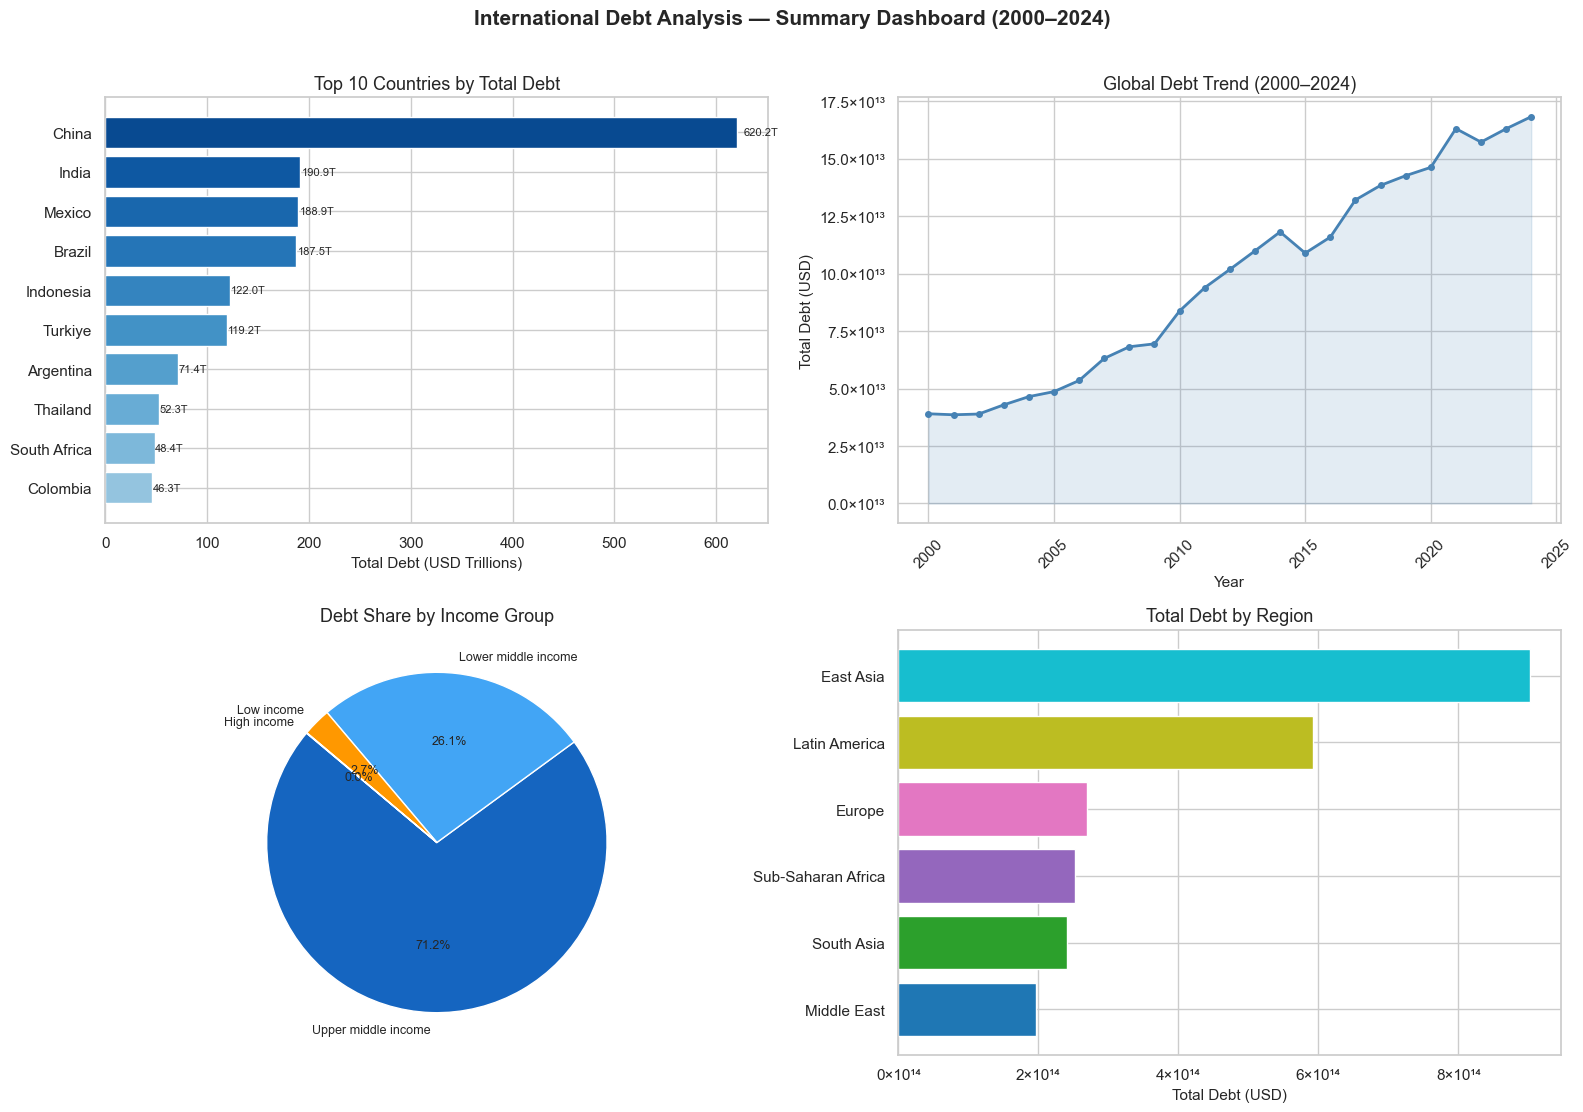

Saved: viz_06_dashboard.png


In [96]:
import numpy as np

fig6, axes = plt.subplots(2, 2, figsize=(16, 11))
fig6.suptitle('International Debt Analysis — Summary Dashboard (2000–2024)',
              fontsize=15, fontweight='bold', y=1.01)

# ── Panel A: Top 10 Countries ─────────────────────────────────────────────
ax = axes[0, 0]
t10 = df_countries.groupby('Country Name')['debt_value'].sum().nlargest(10).reset_index()
t10['T'] = t10['debt_value'] / 1e12
ax.barh(t10['Country Name'][::-1], t10['T'][::-1],
        color=plt.cm.Blues(np.linspace(0.4, 0.9, 10)))
ax.set_title('Top 10 Countries by Total Debt')
ax.set_xlabel('Total Debt (USD Trillions)')
for i, v in enumerate(t10['T'][::-1]):
    ax.text(v * 1.01, i, f'{v:.1f}T', va='center', fontsize=8)

# ── Panel B: Year-wise Trend ──────────────────────────────────────────────
ax = axes[0, 1]
yr = df_countries.groupby('year')['debt_value'].sum().reset_index()
ax.plot(yr['year'], yr['debt_value'], color='steelblue', linewidth=2, marker='o', ms=4)
ax.fill_between(yr['year'], yr['debt_value'], alpha=0.15, color='steelblue')
ax.set_title('Global Debt Trend (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Debt (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e13:.1f}×10¹³'))
ax.tick_params(axis='x', rotation=45)

# ── Panel C: Income Group Pie ─────────────────────────────────────────────
ax = axes[1, 0]
inc_s = (df_countries.dropna(subset=['Income Group'])
         .groupby('Income Group')['debt_value'].sum()
         .sort_values(ascending=False))
ax.pie(inc_s.values, labels=inc_s.index, autopct='%1.1f%%',
       colors=['#1565C0','#42A5F5','#FF9800','#EF5350'],
       startangle=140, textprops={'fontsize': 9})
ax.set_title('Debt Share by Income Group')

# ── Panel D: Region Bar ───────────────────────────────────────────────────
ax = axes[1, 1]
reg_s = (df_countries.dropna(subset=['Region'])
         .groupby('Region')['debt_value'].sum()
         .sort_values())
short_reg = [r.split('&')[0].strip()[:20] for r in reg_s.index]
ax.barh(short_reg, reg_s.values,
        color=plt.cm.tab10(np.linspace(0, 1, len(reg_s))))
ax.set_title('Total Debt by Region')
ax.set_xlabel('Total Debt (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e14:.0f}×10¹⁴'))

plt.tight_layout()
plt.savefig('viz_06_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_06_dashboard.png')

## Step 5 Summary

| File | Chart | Library |
|------|-------|---------|
| `viz_01_top10_bar.html`     | Top 10 Countries — Interactive Bar      | Plotly |
| `viz_02_yearly_trend.html`  | Year-wise Debt Trend + YoY Growth       | Plotly |
| `viz_03_choropleth_map.html`| World Map — Country Debt Choropleth     | Plotly |
| `viz_04_income_stacked.html`| Income Group Debt per Year — Stacked    | Plotly |
| `viz_05_sunburst.html`      | Region › Income Group Sunburst          | Plotly |
| `viz_06_dashboard.png`      | 4-Panel Summary Dashboard               | Matplotlib |

> **Step 7 :** Streamlit interactive dashboard is provided as a **separate `.py` file**